# 02 — Feature Engineering

Build the feature matrix for the updated model by combining:
1. **Meijer 2021 baseline** — river outfall locations + emission targets
2. **HydroRIVERS** — river topology, discharge, Strahler order, upstream area
3. **WorldClim** — precipitation climatology
4. **World Bank What a Waste 3.0** — country-level mismanaged plastic waste rates

Sections 5-8 are placeholders for datasets still being processed:
- ERA5-Land runoff (downloading)
- MERIT Hydro (pending transfer)
- VIIRS nightlights (GEE)
- OSM road density (osmnx)

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import Resampling
from shapely.geometry import Point

sys.path.insert(0, str(Path.cwd().parent / "src"))

DATA_RAW = Path("../data/raw")
DATA_PROC = Path("../data/processed")

## 1. Load Meijer 2021 outfalls (target variable + spatial join key)

In [2]:
shp = gpd.read_file(DATA_RAW / "meijer2021" / "Meijer2021_midpoint_emissions.shp")
shp = shp.rename(columns={"dots_exten": "emission_ton"})
shp["lon"] = shp.geometry.x
shp["lat"] = shp.geometry.y
shp["log_emission"] = np.log10(shp["emission_ton"].clip(lower=1e-3))

outfalls = shp[["emission_ton", "log_emission", "lon", "lat", "geometry"]].copy()
outfalls = outfalls.to_crs(epsg=4326)
print(f"Outfalls: {len(outfalls):,}")
outfalls.head()

Outfalls: 31,819


,emission_ton,log_emission,lon,lat,geometry
0,0.164904,-0.782769,168.797917,-46.580833,POINT (168.79792 -46.58083)
1,0.124932,-0.903326,168.348750,-46.447083,POINT (168.34875 -46.44708)
2,1.213370,0.083993,168.337083,-46.418750,POINT (168.33708 -46.41875)
3,0.121138,-0.916720,168.021250,-46.357917,POINT (168.02125 -46.35792)
4,0.197533,-0.704360,169.811250,-46.343750,POINT (169.81125 -46.34375)


## 2. HydroRIVERS — river topology features

Key columns from HydroRIVERS:
- `DIS_AV_CMS`: mean annual discharge (m³/s)
- `ORD_STRA`: Strahler stream order
- `UPLAND_SKM`: upstream drainage area (km²)
- `LENGTH_KM`: river reach length
- `CATCH_SKM`: catchment area (km²)
- `NEXT_DOWN`: downstream reach ID (topology)
- `MAIN_RIV`: main river identifier

We spatially join each Meijer outfall to the nearest HydroRIVERS reach.

In [3]:
# HydroRIVERS reach attributes — pre-extracted per outfall (memory-safe).
# The nearest-reach join is done by scripts/sample_hydrorivers_at_outfalls.py
# (tiled bbox reads) instead of loading the full 1.5 GB geodatabase here, which OOMs
# on <8 GB machines. Result is aligned to the Meijer outfalls shapefile order.
nearest_dedup = pd.read_csv(DATA_PROC / "hydrorivers_at_outfalls.csv")
print(f"HydroRIVERS (pre-extracted): "
      f"{nearest_dedup['HYRIV_ID'].notna().sum():,} / {len(nearest_dedup):,} matched")


HydroRIVERS (pre-extracted): 31,792 / 31,819 matched


In [4]:
# (moved) nearest-reach join + extended-radius search now live in
# scripts/sample_hydrorivers_at_outfalls.py — see the pre-extracted CSV loaded above.


In [5]:
# (moved) nearest-reach join + extended-radius search now live in
# scripts/sample_hydrorivers_at_outfalls.py — see the pre-extracted CSV loaded above.


In [6]:
# Add hydro features to the feature matrix
# Deduplicate nearest (sjoin_nearest can create multiple matches)
# nearest_dedup already loaded from the pre-extracted CSV above

features = outfalls[["emission_ton", "log_emission", "lon", "lat"]].copy()

hydro_features = [
    "DIS_AV_CMS", "UPLAND_SKM", "CATCH_SKM",
    "ORD_STRA", "LENGTH_KM", "ENDORHEIC",
]
for col in hydro_features:
    features[col] = nearest_dedup[col].values

features["log_discharge"] = np.log10(features["DIS_AV_CMS"].clip(lower=0.01))
features["log_upstream_area"] = np.log10(features["UPLAND_SKM"].clip(lower=0.1))
features["log_catch_area"] = np.log10(features["CATCH_SKM"].clip(lower=0.1))

print(f"Features so far: {list(features.columns)}")
features.describe()


Features so far: ['emission_ton', 'log_emission', 'lon', 'lat', 'DIS_AV_CMS', 'UPLAND_SKM', 'CATCH_SKM', 'ORD_STRA', 'LENGTH_KM', 'ENDORHEIC', 'log_discharge', 'log_upstream_area', 'log_catch_area']


,emission_ton,log_emission,lon,lat,DIS_AV_CMS,UPLAND_SKM,CATCH_SKM,ORD_STRA,LENGTH_KM,ENDORHEIC,log_discharge,log_upstream_area,log_catch_area
count,31819.000000,31819.000000,31819.000000,31819.000000,31792.000000,3.179200e+04,31792.000000,31792.000000,31792.000000,31792.000000,31792.000000,31792.000000,31792.000000
mean,31.615832,0.269192,66.487344,11.065975,31.808788,2.105951e+03,11.555304,2.025635,3.804196,0.001415,0.070436,1.616463,0.841712
std,416.877329,0.909172,76.568565,18.560880,1255.317653,5.399117e+04,13.398389,1.202371,3.616606,0.037596,0.789397,0.876525,0.456497
min,0.000000,-3.000000,-135.327083,-54.882083,0.000000,1.000000e+00,0.180000,1.000000,0.270000,0.000000,-2.000000,0.000000,-0.744727
25%,0.334101,-0.476123,9.485000,-1.580833,0.303000,9.200000e+00,3.600000,1.000000,1.430000,0.000000,-0.518557,0.963788,0.556302
50%,1.294220,0.112008,101.963750,10.184583,0.810000,2.840000e+01,7.150000,2.000000,2.690000,0.000000,-0.091515,1.453318,0.854306
75%,7.243510,0.859949,122.238750,20.205625,3.064000,1.243000e+02,14.560000,3.000000,4.920000,0.000000,0.486289,2.094471,1.163161
max,62591.900000,4.796518,179.947083,59.803750,205603.687500,5.912761e+06,209.610001,10.000000,52.430000,1.000000,5.313031,6.771790,2.321412


## 3. WorldClim — precipitation climatology

Extract mean annual precipitation at each outfall location from the 12 monthly
WorldClim v2.1 rasters (2.5 arcmin resolution).

In [7]:
precip_files = sorted((DATA_RAW / "worldclim").glob("wc2.1_2.5m_prec_??.tif"))
print(f"Found {len(precip_files)} monthly precipitation files")

coords = [(row.lon, row.lat) for row in outfalls.itertuples()]

precip_stack = []
for f in precip_files:
    with rasterio.open(f) as src:
        values = [x[0] for x in src.sample(coords)]
        precip_stack.append(values)

precip_arr = np.array(precip_stack).T
monthly_cols = [f"precip_mm_{m:02d}" for m in range(1, 13)]

precip_df = pd.DataFrame(precip_arr, columns=monthly_cols, index=features.index)
precip_df["precip_annual_mm"] = precip_df.sum(axis=1)
precip_df["precip_max_month_mm"] = precip_df[monthly_cols].max(axis=1)
precip_df["precip_cv"] = precip_df[monthly_cols].std(axis=1) / precip_df[monthly_cols].mean(axis=1).clip(lower=1)

features = pd.concat([features, precip_df], axis=1)
print(f"Added {len(precip_df.columns)} precipitation features")
features[["precip_annual_mm", "precip_max_month_mm", "precip_cv"]].describe()

Found 12 monthly precipitation files


Added 15 precipitation features


,precip_annual_mm,precip_max_month_mm,precip_cv
count,31819.000000,31819.000000,31819.000000
mean,-2267.909959,-12.822465,0.578078
std,41361.430643,3471.890854,0.335064
min,-393216.000000,-32768.000000,0.000000
25%,1286.000000,207.000000,0.311714
50%,2047.000000,303.000000,0.513040
75%,2799.000000,418.000000,0.782700
max,6737.000000,1432.000000,2.920772


## 4. World Bank What a Waste 3.0 — country-level waste data

Updated waste generation and mismanagement rates from the World Bank's
What a Waste 3.0 dataset (2026, data through 2022). This replaces the
What a Waste 3.0 dataset, replacing the Jambeck 2015 data used in the original Meijer model.

Key fields:
- Waste generation rate (kg/person/day)
- Plastic fraction of MSW (%)
- Collection coverage (%)
- Mismanaged waste fraction (%)
- Mismanaged plastic waste per capita (kg/capita/day)

We assign each outfall to a country using its coordinates, then merge waste rates.

In [8]:
# Reverse geocode outfalls to country using Natural Earth boundaries
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
world = world[["NAME", "ISO_A3", "CONTINENT", "geometry"]].rename(columns={
    "NAME": "name", "ISO_A3": "iso_a3", "CONTINENT": "continent"
}).copy()
world = world.to_crs(epsg=4326)
print(f"Countries: {len(world)}")
world.head()


Countries: 177


,name,iso_a3,continent,geometry
0,Fiji,FJI,Oceania,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Tanzania,TZA,Africa,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,W. Sahara,ESH,Africa,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Canada,CAN,North America,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,United States of America,USA,North America,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [9]:
# Spatial join outfalls -> countries
outfalls_gdf = gpd.GeoDataFrame(
    outfalls,
    geometry=[Point(xy) for xy in zip(outfalls.lon, outfalls.lat)],
    crs="EPSG:4326",
)

country_join = gpd.sjoin(outfalls_gdf, world, how="left", predicate="within")
features["country_iso"] = country_join["iso_a3"].values
features["continent"] = country_join["continent"].values

matched = features["country_iso"].notna().sum()
print(f"Country matched: {matched:,} / {len(features):,}")
print(f"Top countries by outfall count:")
features["country_iso"].value_counts().head(20)

Country matched: 20,833 / 31,819
Top countries by outfall count:


country_iso
IDN    2975
PHL    2457
MMR    1373
CHN    1048
BRA    1033
USA     806
MYS     752
PNG     747
JPN     716
TUR     488
IND     465
THA     415
GBR     352
BGD     331
MEX     314
VNM     291
ITA     283
PAN     265
NGA     264
SLB     216
Name: count, dtype: int64

In [10]:
# World Bank What a Waste 3.0 — country-level waste data
# Source: https://datacatalog.worldbank.org/search/dataset/0039597

waw = pd.read_excel(
    DATA_RAW / "worldbank_waste" / "what_a_waste_3.0_country.xlsx",
    sheet_name="Country dataset",
)

# Convert numeric columns (some have header rows repeated as strings)
skip = {"Country code", "Region", "Country name ", "Income group (waste generation year)", "Income group (2022)"}
for col in waw.columns:
    if col not in skip:
        waw[col] = pd.to_numeric(waw[col], errors="coerce")

# Build waste lookup table
waste = pd.DataFrame()
waste["country_iso"] = waw["Country code"]
waste["waste_kg_cap_day"] = waw["MSW generation (kg/capita/day)"]
waste["plastic_pct"] = waw["Composition - plastic (% weight MSW)"] * 100  # values are 0-1
waste["collection_pct"] = waw["Collection coverage - total (% population)"] * 100

# Mismanaged = open dump + uncollected (as % of MSW)
open_dump = waw["Treatment - open dump (% weight MSW generated)"] * 100
uncollected = waw["Treatment - uncollected (% weight MSW generated)"] * 100
waste["mismanaged_pct"] = open_dump.fillna(0) + uncollected.fillna(0)

# Where treatment data is missing, use 100 - collection rate
no_treatment = open_dump.isna() & uncollected.isna()
waste.loc[no_treatment, "mismanaged_pct"] = 100 - waste.loc[no_treatment, "collection_pct"].fillna(50)

# Fill remaining gaps with income-group median
waste["income_group"] = waw["Income group (2022)"]
income_med = waste.groupby("income_group")["mismanaged_pct"].transform("median")
still_zero = (waste["mismanaged_pct"] == 0) & no_treatment
waste.loc[still_zero, "mismanaged_pct"] = income_med[still_zero]
waste["mismanaged_pct"] = waste["mismanaged_pct"].clip(0, 100)

# MPW per capita per day
waste["plastic_fraction"] = waste["plastic_pct"].fillna(12) / 100
waste["mpw_kg_cap_day"] = waste["waste_kg_cap_day"] * waste["plastic_fraction"] * (waste["mismanaged_pct"] / 100)

print(f"Countries with waste data: {len(waste)}")
print(f"MPW coverage: {waste.mpw_kg_cap_day.notna().sum()}/{len(waste)}")
waste.sort_values("mpw_kg_cap_day", ascending=False).head(10)[["country_iso", "waste_kg_cap_day", "plastic_pct", "mismanaged_pct", "mpw_kg_cap_day"]]

Countries with waste data: 218
MPW coverage: 205/218


,country_iso,waste_kg_cap_day,plastic_pct,mismanaged_pct,mpw_kg_cap_day
15,BHR,2.826680,29.98,50.0,0.423719
14,BHS,3.483177,NaN,100.0,0.417981
22,BMU,3.108162,19.00,50.0,0.295275
29,BRN,1.849483,29.00,50.0,0.268175
213,VIR,3.789475,13.60,50.0,0.257684
148,OMN,2.001936,25.66,50.0,0.256848
106,KWT,2.187359,20.00,50.0,0.218736
98,JAM,1.187443,18.00,100.0,0.213740
130,MCO,3.250055,NaN,50.0,0.195003
37,CYM,3.231781,NaN,50.0,0.193907


In [11]:
# Merge waste data into features
features = features.merge(
    waste[["country_iso", "waste_kg_cap_day", "mismanaged_pct", "plastic_pct", "mpw_kg_cap_day"]],
    on="country_iso",
    how="left",
)

matched_waste = features["waste_kg_cap_day"].notna().sum()
print(f"Outfalls with waste data: {matched_waste:,} / {len(features):,}")
print(f"Missing waste data for {features['waste_kg_cap_day'].isna().sum():,} outfalls")

# Fill missing with continental median
continental_median = features.groupby("continent")["mpw_kg_cap_day"].transform("median")
features["mpw_kg_cap_day"] = features["mpw_kg_cap_day"].fillna(continental_median)
features["waste_kg_cap_day"] = features["waste_kg_cap_day"].fillna(
    features.groupby("continent")["waste_kg_cap_day"].transform("median")
)
features["mismanaged_pct"] = features["mismanaged_pct"].fillna(
    features.groupby("continent")["mismanaged_pct"].transform("median")
)
features["plastic_pct"] = features["plastic_pct"].fillna(12.0)

print(f"\nAfter fill — remaining NaN: {features['mpw_kg_cap_day'].isna().sum()}")

Outfalls with waste data: 20,265 / 31,819
Missing waste data for 11,554 outfalls

After fill — remaining NaN: 10986


In [12]:
# Estimate catchment-level MPW using upstream area as population proxy
# (This is a simplification — Meijer uses LandScan population grid)
# MPW_total = mpw_per_cap * population ≈ mpw_per_cap * pop_density * upstream_area
# For now, use mpw_kg_cap_day as the per-capita rate feature
# The full model will use LandScan population × catchment boundaries

features["log_mpw_rate"] = np.log10(features["mpw_kg_cap_day"].clip(lower=1e-4))
features[["mpw_kg_cap_day", "log_mpw_rate"]].describe()

,mpw_kg_cap_day,log_mpw_rate
count,20833.000000,20833.000000
mean,0.044183,-1.705412
std,0.043019,0.799067
min,0.000000,-4.000000
25%,0.019410,-1.711983
50%,0.031737,-1.498439
75%,0.052907,-1.276486
max,0.417981,-0.378843


## 5. ERA5-Land runoff (placeholder)

When the ERA5 download completes, extract:
- Mean annual runoff per catchment
- Runoff coefficient of variation (interannual variability)
- Runoff anomaly 2020-2024 vs 2015-2019 baseline

This replaces the GRUN runoff climatology used by Meijer.

In [13]:
# ERA5-Land runoff — NOT USED in the analysis (unit mismatch documented in DEV_NOTES;
# r=0.74 with WorldClim, no significant trend). Loading the 1.2 GB global .nc eagerly with
# xarray OOMs on <8 GB machines, and these features never feed the calibration/ranking.
# Kept as NaN placeholder columns so the feature-matrix schema is unchanged.
features["runoff_mean_mm_yr"] = np.nan
features["runoff_cv"] = np.nan
features["runoff_anomaly"] = np.nan
print("ERA5 runoff: skipped (not used; placeholder NaN columns) — see DEV_NOTES")


ERA5 runoff: skipped (not used; placeholder NaN columns) — see DEV_NOTES


## 6. MERIT Hydro (placeholder)

When MERIT Hydro tiles are available, extract:
- Channel width (chw)
- Elevation / slope (elv)
- Flow direction (dir)
- Upstream drainage area (upa) — cross-validate with HydroRIVERS

Alternative: use Google Earth Engine `MERIT/Hydro/v1_0_1`.

In [14]:
merit_dir = DATA_RAW / "merit_hydro"
merit_tiles = list(merit_dir.glob("**/*.tif"))

if merit_tiles:
    print(f"Found {len(merit_tiles)} MERIT Hydro tiles")
else:
    print("MERIT Hydro tiles not available yet")
    print("Adding placeholder columns...")
    features["channel_width_m"] = np.nan
    features["elevation_m"] = np.nan
    features["slope_pct"] = np.nan

MERIT Hydro tiles not available yet
Adding placeholder columns...


## 7. VIIRS nightlights & OSM roads (placeholder)

These will be extracted via Google Earth Engine (VIIRS) and osmnx (OSM).

In [15]:
# VIIRS nightlights — load pre-extracted values
viirs = pd.read_csv(DATA_PROC / "viirs_nightlight_at_outfalls.csv")
features["nightlight_intensity"] = viirs["nightlight_intensity"].values

n_valid = features["nightlight_intensity"].notna().sum()
print(f"VIIRS nightlight: {n_valid:,} / {len(features):,} outfalls covered")
features[["nightlight_intensity"]].describe()


VIIRS nightlight: 31,819 / 31,819 outfalls covered


,nightlight_intensity
count,31819.000000
mean,3.871288
std,11.472006
min,-1.500000
25%,0.000000
50%,0.309507
75%,2.252491
max,501.168915


## 8. Feature summary and correlation

In [16]:
print(f"Feature matrix: {features.shape}")
print(f"Columns: {list(features.columns)}")
print()
print("Non-null counts:")
print(features.notna().sum())
print()
print("Data types:")
print(features.dtypes)

Feature matrix: (31819, 42)
Columns: ['emission_ton', 'log_emission', 'lon', 'lat', 'DIS_AV_CMS', 'UPLAND_SKM', 'CATCH_SKM', 'ORD_STRA', 'LENGTH_KM', 'ENDORHEIC', 'log_discharge', 'log_upstream_area', 'log_catch_area', 'precip_mm_01', 'precip_mm_02', 'precip_mm_03', 'precip_mm_04', 'precip_mm_05', 'precip_mm_06', 'precip_mm_07', 'precip_mm_08', 'precip_mm_09', 'precip_mm_10', 'precip_mm_11', 'precip_mm_12', 'precip_annual_mm', 'precip_max_month_mm', 'precip_cv', 'country_iso', 'continent', 'waste_kg_cap_day', 'mismanaged_pct', 'plastic_pct', 'mpw_kg_cap_day', 'log_mpw_rate', 'runoff_mean_mm_yr', 'runoff_cv', 'runoff_anomaly', 'channel_width_m', 'elevation_m', 'slope_pct', 'nightlight_intensity']

Non-null counts:
emission_ton            31819
log_emission            31819
lon                     31819
lat                     31819
DIS_AV_CMS              31792
UPLAND_SKM              31792
CATCH_SKM               31792
ORD_STRA                31792
LENGTH_KM               31792
ENDORHE

In [17]:
# Correlation of available features with log emission
numeric_cols = features.select_dtypes(include=[np.number]).columns
numeric_cols = [c for c in numeric_cols if c not in ("emission_ton", "log_emission")]

corr = features[["log_emission"] + numeric_cols].corr()["log_emission"].drop("log_emission").sort_values(ascending=False)
print("Correlation with log10(emission):")
print(corr.to_string())

Correlation with log10(emission):
log_discharge           0.351853
ORD_STRA                0.326116
log_upstream_area       0.300899
precip_cv               0.175591
nightlight_intensity    0.117142
lon                     0.059744
UPLAND_SKM              0.059250
DIS_AV_CMS              0.042994
LENGTH_KM               0.008902
precip_max_month_mm     0.007033
precip_mm_07            0.006266
precip_mm_08            0.004710
lat                     0.004168
precip_mm_06            0.003712
precip_mm_09            0.002512
precip_mm_10            0.002062
precip_mm_11            0.000419
precip_annual_mm       -0.000678
precip_mm_05           -0.001964
precip_mm_12           -0.002358
precip_mm_01           -0.005266
precip_mm_04           -0.005581
precip_mm_02           -0.005941
precip_mm_03           -0.006783
ENDORHEIC              -0.012623
CATCH_SKM              -0.016123
plastic_pct            -0.044124
log_catch_area         -0.054659
mismanaged_pct         -0.094709
log_mpw_r

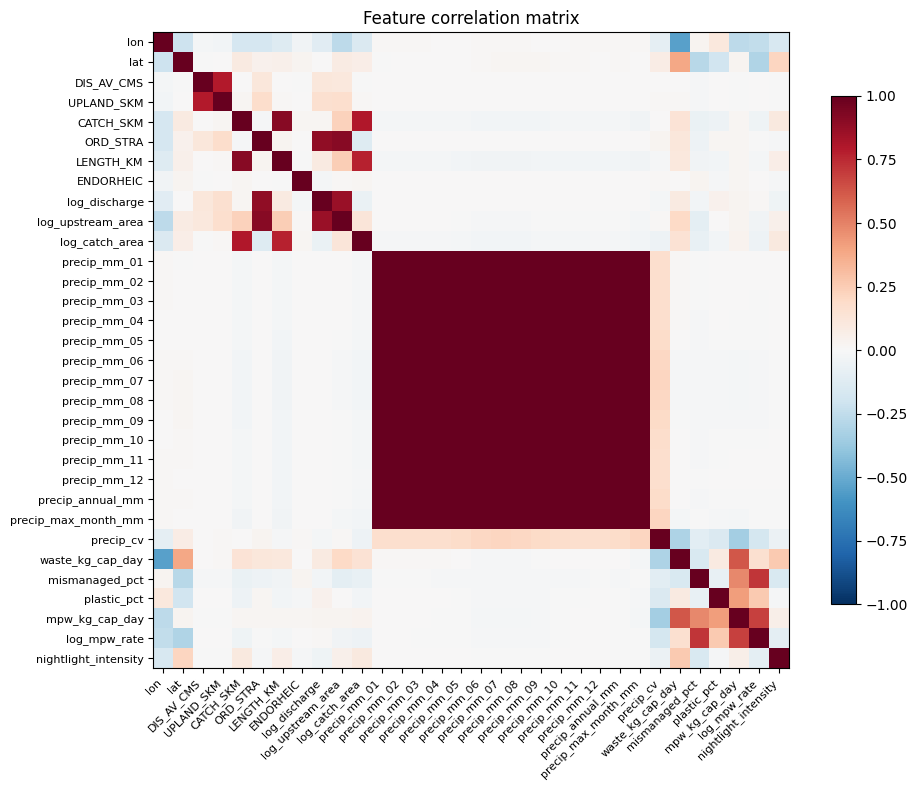

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))
available = [c for c in numeric_cols if features[c].notna().sum() > 100]
corr_matrix = features[available].corr()
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(available)))
ax.set_yticks(range(len(available)))
ax.set_xticklabels(available, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(available, fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.savefig("../results/figures/02_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Save feature matrix

In [19]:
features.to_csv(DATA_PROC / "feature_matrix_v1.csv", index=False)
print(f"Saved {features.shape[0]:,} rivers × {features.shape[1]} features to feature_matrix_v1.csv")
print()
print("Feature inventory:")
for col in features.columns:
    n_valid = features[col].notna().sum()
    src = (
        "Meijer" if col in ("emission_ton", "log_emission", "lon", "lat") else
        "HydroRIVERS" if col in ("DIS_AV_CMS", "UPLAND_SKM", "CATCH_SKM", "ORD_STRA", "LENGTH_KM", "ENDORHEIC", "log_discharge", "log_upstream_area", "log_catch_area") else
        "WorldClim" if "precip" in col else
        "What a Waste 3.0" if col in ("waste_kg_cap_day", "mismanaged_pct", "plastic_pct", "mpw_kg_cap_day", "log_mpw_rate") else
        "ERA5" if "runoff" in col else
        "Geocode" if col in ("country_iso", "continent") else
        "Pending"
    )
    print(f"  {col:30s} {n_valid:>6,} / {len(features):,}  [{src}]")

Saved 31,819 rivers × 42 features to feature_matrix_v1.csv

Feature inventory:
  emission_ton                   31,819 / 31,819  [Meijer]
  log_emission                   31,819 / 31,819  [Meijer]
  lon                            31,819 / 31,819  [Meijer]
  lat                            31,819 / 31,819  [Meijer]
  DIS_AV_CMS                     31,792 / 31,819  [HydroRIVERS]
  UPLAND_SKM                     31,792 / 31,819  [HydroRIVERS]
  CATCH_SKM                      31,792 / 31,819  [HydroRIVERS]
  ORD_STRA                       31,792 / 31,819  [HydroRIVERS]
  LENGTH_KM                      31,792 / 31,819  [HydroRIVERS]
  ENDORHEIC                      31,792 / 31,819  [HydroRIVERS]
  log_discharge                  31,792 / 31,819  [HydroRIVERS]
  log_upstream_area              31,792 / 31,819  [HydroRIVERS]
  log_catch_area                 31,792 / 31,819  [HydroRIVERS]
  precip_mm_01                   31,819 / 31,819  [WorldClim]
  precip_mm_02                   31,819 / 31,81